In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import zscore, skew, kurtosis

# ==============================
# 1. CARREGAMENTO
# ==============================

features = pd.read_csv("datasets/elliptic_txs_features.csv", header=None)
edges = pd.read_csv("datasets/elliptic_txs_edgelist.csv")
classes = pd.read_csv("datasets/elliptic_txs_classes.csv")

features.rename(columns={0: "txId"}, inplace=True)

df = features.merge(classes, on="txId", how="left")

# Mantém unknown
df["class"] = df["class"].astype(str)

# ==============================
# 2. ESTATÍSTICAS GERAIS
# ==============================

print("\n===== ESTATÍSTICAS GERAIS =====")
print("Número total de nós:", df.shape[0])
print("Número de features:", df.shape[1] - 2)

print("\nDistribuição de classes (%):")
print(df["class"].value_counts(normalize=True) * 100)

# ==============================
# 3. OUTLIERS (somente features)
# ==============================

numeric_cols = df.drop(columns=["txId", "class"]).columns

# Z-score
z_scores = np.abs(zscore(df[numeric_cols], nan_policy='omit'))
outliers_z = (z_scores > 3).sum().sum()
total_values = df[numeric_cols].shape[0] * df[numeric_cols].shape[1]
outlier_z_pct = (outliers_z / total_values) * 100

# IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum().sum()

outlier_iqr_pct = (outliers_iqr / total_values) * 100

print(f"\nOutliers Z-score (%): {outlier_z_pct:.2f}")
print(f"Outliers IQR (%): {outlier_iqr_pct:.2f}")

# ==============================
# 4. CONSTRUÇÃO DO GRAFO
# ==============================

G = nx.from_pandas_edgelist(edges, source="txId1", target="txId2")

print("\n===== MÉTRICAS DE GRAFO =====")
print("Número de nós no grafo:", G.number_of_nodes())
print("Número de arestas:", G.number_of_edges())
print("Densidade:", nx.density(G))
print("Componentes conectados:", nx.number_connected_components(G))

degrees = dict(G.degree())
degree_values = list(degrees.values())

print("Grau médio:", np.mean(degree_values))
print("Grau máximo:", np.max(degree_values))
print("Desvio padrão do grau:", np.std(degree_values))

# ==============================
# 5. CENTRALIDADES
# ==============================

print("\nCalculando centralidades...")

degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=500)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G)

centralities = pd.DataFrame({
    "txId": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values()),
    "betweenness": list(betweenness.values()),
    "closeness": list(closeness.values()),
    "pagerank": list(pagerank.values())
})

df = df.merge(centralities, on="txId", how="left")

# ==============================
# 6. MÉDIAS POR CLASSE (incluindo unknown)
# ==============================

print("\n===== CENTRALIDADES MÉDIAS POR CLASSE =====")
print(df.groupby("class")[[
    "degree_centrality",
    "betweenness",
    "closeness",
    "pagerank"
]].mean())

# ==============================
# 7. ESTATÍSTICAS DAS FEATURES
# ==============================

stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "std": df[numeric_cols].std(),
    "skew": df[numeric_cols].apply(skew),
    "kurtosis": df[numeric_cols].apply(kurtosis)
})

stats.to_csv("elliptic_feature_statistics.csv")

print("\nAnálise concluída e exportada.")


===== ESTATÍSTICAS GERAIS =====
Número total de nós: 203769
Número de features: 166

Distribuição de classes (%):
class
unknown    77.148634
2          20.620899
1           2.230467
Name: proportion, dtype: float64

Outliers Z-score (%): 1.29
Outliers IQR (%): 13.41

===== MÉTRICAS DE GRAFO =====
Número de nós no grafo: 203769
Número de arestas: 234355
Densidade: 1.1288341056918834e-05
Componentes conectados: 49
Grau médio: 2.3002026804862368
Grau máximo: 473
Desvio padrão do grau: 4.328366155605154

Calculando centralidades...


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7489c77ef0e0>>
Traceback (most recent call last):
  File "/home/vitor/anaconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# ==============================
# 1. CARREGAMENTO
# ==============================

features = pd.read_csv("datasets/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("datasets/elliptic_txs_classes.csv")
edges = pd.read_csv("datasets/elliptic_txs_edgelist.csv")

features = features.rename(columns={0: "txId"})
df = features.merge(classes, on="txId", how="left")

# Mantém unknown
df["class"] = df["class"].astype(str)

numeric_cols = df.drop(columns=["txId", "class"]).columns

# ==============================
# 2. CONSTRUÇÃO DO GRAFO
# ==============================

G = nx.from_pandas_edgelist(
    edges, source="txId1", target="txId2", create_using=nx.DiGraph()
)

# adicionar atributo class aos nós (incluindo unknown)
class_dict = df.set_index("txId")["class"].to_dict()
nx.set_node_attributes(G, class_dict, "class")

# ==============================
# 3. ASSORTATIVIDADE
# ==============================

assortativity = nx.attribute_assortativity_coefficient(G, "class")
print("\nAssortatividade por classe:", assortativity)

# ==============================
# 4. CLUSTERING COEFFICIENT POR CLASSE
# ==============================

clustering = nx.clustering(G.to_undirected())
df["clustering"] = df["txId"].map(clustering)

print("\nClustering médio por classe:")
print(df.groupby("class")["clustering"].mean())

# ==============================
# 5. DISTRIBUIÇÃO DE GRAU POR CLASSE
# ==============================

degrees = dict(G.degree())
df["degree"] = df["txId"].map(degrees)

plt.figure()
sns.histplot(data=df, x="degree", hue="class", bins=50, kde=True)
plt.title("Distribuição de Grau por Classe")
plt.savefig("elliptic_degree_distribution.png")
plt.close()

# ==============================
# 6. CORRELAÇÃO (Pearson + Spearman)
# ==============================

pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

pearson_corr.to_csv("elliptic_pearson_corr.csv")
spearman_corr.to_csv("elliptic_spearman_corr.csv")

# ==============================
# 7. KOLMOGOROV-SMIRNOV (3 comparações)
# ==============================

ks_results = []

classes_unique = df["class"].unique()

for col in numeric_cols:
    for i in range(len(classes_unique)):
        for j in range(i+1, len(classes_unique)):
            c1 = classes_unique[i]
            c2 = classes_unique[j]

            group1 = df[df["class"] == c1][col]
            group2 = df[df["class"] == c2][col]

            stat, p = ks_2samp(group1, group2)
            ks_results.append((col, c1, c2, stat, p))

ks_df = pd.DataFrame(
    ks_results,
    columns=["feature", "class_1", "class_2", "ks_stat", "p_value"]
)

ks_df.sort_values("ks_stat", ascending=False).to_csv(
    "elliptic_ks_test_all_classes.csv", index=False
)

# ==============================
# 8. MUTUAL INFORMATION (multiclasse)
# ==============================

le = LabelEncoder()
y_encoded = le.fit_transform(df["class"])

mi = mutual_info_classif(df[numeric_cols], y_encoded)

mi_df = pd.DataFrame({"feature": numeric_cols, "mi": mi})
top_features = mi_df.sort_values("mi", ascending=False)["feature"].head(5)

for col in top_features:
    plt.figure()
    sns.boxplot(x="class", y=col, data=df)
    plt.title(f"Boxplot - {col}")
    plt.savefig(f"elliptic_boxplot_{col}.png")
    plt.close()

print("\nEDA estrutural Elliptic concluída.")


Assortatividade por classe: 0.3402500156924627

Clustering médio por classe:
class
1          0.000356
2          0.008320
unknown    0.015604
Name: clustering, dtype: float64

EDA estrutural Elliptic concluída.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# =============================
# 1. CARREGAMENTO
# =============================

features = pd.read_csv("datasets/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("datasets/elliptic_txs_classes.csv")

features.rename(columns={0: "txId"}, inplace=True)
df_full = features.merge(classes, on="txId", how="left")

# Dataset completo (inclui unknown)
df_all = df_full.copy()

# Dataset apenas rotulado
df_labeled = df_full[df_full["class"] != "unknown"].copy()
df_labeled["class"] = df_labeled["class"].astype(int)

# =============================
# 2. FUNÇÃO PARA CALCULAR MÉTRICAS
# =============================

def compute_outlier_metrics(df, label):
    numeric_cols = df.select_dtypes(include=np.number).drop(columns=["class"], errors="ignore").columns
    
    # Z-score
    z_scores = np.abs(zscore(df[numeric_cols], nan_policy="omit"))
    outliers_z = (z_scores > 3).sum().sum()
    total_values = df[numeric_cols].shape[0] * df[numeric_cols].shape[1]
    outlier_z_pct = (outliers_z / total_values) * 100
    
    # IQR
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers_iqr = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                    (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum().sum()
    
    outlier_iqr_pct = (outliers_iqr / total_values) * 100
    
    return {
        "Dataset": label,
        "Observações": df.shape[0],
        "Outliers_Z_%": round(outlier_z_pct, 4),
        "Outliers_IQR_%": round(outlier_iqr_pct, 4)
    }

# =============================
# 3. EXECUÇÃO
# =============================

results = []
results.append(compute_outlier_metrics(df_all, "Completo"))
results.append(compute_outlier_metrics(df_labeled, "Apenas Rotulado"))

results_df = pd.DataFrame(results)

print("\nComparação de Outliers:")
print(results_df)

results_df.to_csv("comparacao_outliers_elliptic.csv", index=False)


Comparação de Outliers:
           Dataset  Observações  Outliers_Z_%  Outliers_IQR_%
0         Completo       203769        1.2842         13.3315
1  Apenas Rotulado        46564        0.8657         16.5419


“O arquivo de atributos do dataset Elliptic não contém cabeçalho explícito, sendo a primeira coluna correspondente ao identificador da transação e as colunas subsequentes representando 166 atributos numéricos normalizados, conforme especificado na documentação original do dataset.”

# Elliptic

## EDA

In [2]:
import pandas as pd

features = pd.read_csv("datasets/elliptic_txs_features.csv", header=None)
edges = pd.read_csv("datasets/elliptic_txs_edgelist.csv")
labels = pd.read_csv("datasets/elliptic_txs_classes.csv")

labels['class'] = labels['class'].replace({'unknown': -1, '1': 1, '2': 0})

df_elliptic = features.copy()
df_elliptic['label'] = labels['class']
df_elliptic = df_elliptic[df_elliptic['label'] != -1]


/tmp/ipykernel_229995/2946101579.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels['class'] = labels['class'].replace({'unknown': -1, '1': 1, '2': 0})


In [3]:
features.rename(columns={0: "txId"}, inplace=True)


In [4]:
features.head()



,txId,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [5]:
features.shape

(203769, 167)

In [6]:
df_elliptic.shape

(46564, 168)

In [7]:
elliptic_stats = {
    "Nº Instâncias": df_elliptic.shape[0],
    "Nº Features": df_elliptic.shape[1] - 1,
    "% Fraude": (df_elliptic['label'] == 1).mean() * 100,
    "% Não Fraude": (df_elliptic['label'] == 0).mean() * 100
}


In [8]:
import pandas as pd

# “O dataset Elliptic é composto por N transações (nós).”
n_nodes = features.shape[0]

n_nodes




203769

In [9]:
# Cada linha em elliptic_txs_edgelist.csv representa uma aresta dirigida.
# Mencionar depois se tratou o grafo como dirigido ou não — mas isso não agora.
n_edges = edges.shape[0]

n_edges


234355

In [10]:

# “Cada nó é descrito por F atributos numéricos extraídos do comportamento transacional.”
n_features = features.shape[1] - 1  # exclui txId

n_features

166

In [11]:
classes = pd.read_csv("datasets/elliptic_txs_classes.csv")

classes['class'].value_counts()


class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [12]:
# Isso é fundamental para justificar filtragem posterior.
n_labeled = classes[classes['class'] != 0].shape[0]
n_unlabeled = classes[classes['class'] == 0].shape[0]

n_labeled, n_unlabeled


(203769, 0)

In [13]:
classes['class'] = classes['class'].replace('unknown', None)
classes['class'] = classes['class'].astype('float')


In [14]:
labeled = classes.dropna(subset=['class'])

pct_illicit = (labeled['class'] == 1).mean() * 100
pct_licit = (labeled['class'] == 2).mean() * 100


In [15]:

pct_illicit, pct_licit


(np.float64(9.760759384932566), np.float64(90.23924061506743))

In [16]:
classes['class'] = classes['class'].replace('unknown', '0')
classes['class'] = classes['class'].astype('float')
total = classes

pct_illicit = (total['class'] == 1).mean() * 100
pct_licit   = (total['class'] == 2).mean() * 100

pct_illicit, pct_licit


(np.float64(2.2304668521708404), np.float64(20.62089915541618))

In [17]:
total = len(labeled)

pct_illicit = (labeled['class'].eq(1).sum() / total) * 100
pct_licit = (labeled['class'].eq(2).sum() / total) * 100


In [18]:
# “Observa-se um forte desbalanceamento entre transações lícitas e ilícitas.”
class_counts = labeled['class'].value_counts()

imbalance_ratio = class_counts.max() / class_counts.min()
imbalance_ratio


9.245104510451045

In [19]:
import networkx as nx
import numpy as np

'''
📌 Esses números sustentam:

- complexidade da rede

- potencial de propagação de informação ilícita
'''

G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

graph_stats = {
    "Nós": G.number_of_nodes(),
    "Arestas": G.number_of_edges(),
    "Grau médio": np.mean([d for _, d in G.degree()]),
    "Grau máximo": max(dict(G.degree()).values()),
    "Densidade": nx.density(G)
}

graph_stats


{'Nós': 203769,
 'Arestas': 234355,
 'Grau médio': np.float64(2.3002026804862368),
 'Grau máximo': 473,
 'Densidade': 5.644170528459417e-06}

In [20]:
features.columns

Index(['txId',      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
          157,    158,    159,    160,    161,    162,    163,    164,    165,
          166],
      dtype='object', length=167)

In [21]:
''' 📌 Se existir pequena discrepância, é normal e explicável. '''
# nós presentes nas features
nodes_features = set(features['txId'])

# nós presentes nas arestas
nodes_edges = set(edges['txId1']).union(set(edges['txId2']))

# interseção
len(nodes_features.intersection(nodes_edges))


203769

Valores de referência (artigo original Elliptic)
Segundo Weber et al. (2019):

| Métrica              | Valor esperado |
| -------------------- | -------------- |
| Nós (transações)     | ~203.769       |
| Arestas              | ~234.355       |
| Features             | 166            |
| Ilícitas (rotuladas) | ~2%            |
| Lícitas (rotuladas)  | ~98%           |
| Nós não rotulados    | maioria        |


“Embora a literatura frequentemente reporte que aproximadamente 2% das transações no dataset Elliptic sejam ilícitas, esse valor considera o conjunto total de nós, incluindo transações não rotuladas. Ao restringir a análise apenas às transações com rótulo conhecido, conforme requerido em cenários de aprendizado supervisionado, observa-se que cerca de 9,8% das instâncias correspondem a atividades ilícitas.”

In [22]:
print("Nós:", n_nodes)
print("Arestas:", n_edges)
print("Features:", n_features)
print("Ilícitas (%):", round(pct_illicit, 2))
print("Lícitas (%):", round(pct_licit, 2))


Nós: 203769
Arestas: 234355
Features: 166
Ilícitas (%): 9.76
Lícitas (%): 90.24


## A) Organização das Tabelas (Elliptic)

Tabela 1 — Estatísticas gerais do dataset Elliptic.

In [23]:
import pandas as pd

tabela_elliptic_geral = pd.DataFrame({
    "Estatística": [
        "Número de nós (transações)",
        "Número de arestas",
        "Número de atributos por nó",
        "Nós rotulados",
        "Nós não rotulados",
        "Transações ilícitas (%)",
        "Transações lícitas (%)",
        "Razão de desbalanceamento"
    ],
    "Valor": [
        n_nodes,
        n_edges,
        n_features,
        n_labeled,
        n_unlabeled,
        round(pct_illicit, 2),
        round(pct_licit, 2),
        round(imbalance_ratio, 2)
    ]
})

tabela_elliptic_geral


,Estatística,Valor
0,Número de nós (transações),203769.00
1,Número de arestas,234355.00
2,Número de atributos por nó,166.00
3,Nós rotulados,203769.00
4,Nós não rotulados,0.00
5,Transações ilícitas (%),9.76
6,Transações lícitas (%),90.24
7,Razão de desbalanceamento,9.25


Tabela 2 — Estatísticas estruturais do grafo Elliptic

In [24]:
tabela_elliptic_grafo = pd.DataFrame({
    "Métrica": [
        "Número de nós",
        "Número de arestas",
        "Grau médio",
        "Grau máximo",
        "Densidade"
    ],
    "Valor": [
        graph_stats["Nós"],
        graph_stats["Arestas"],
        round(graph_stats["Grau médio"], 4),
        graph_stats["Grau máximo"],
        round(graph_stats["Densidade"], 6)
    ]
})

tabela_elliptic_grafo


,Métrica,Valor
0,Número de nós,203769.000000
1,Número de arestas,234355.000000
2,Grau médio,2.300200
3,Grau máximo,473.000000
4,Densidade,0.000006


## B) Estatísticas descritivas das features (Elliptic)

- Distribuição global
- Heterogeneidade
- Presença de outliers
- Escala dos atributos

In [25]:
# Separar somente as features (sem o txId)
X_elliptic = features.drop(columns=["txId"])


In [26]:
# Estatísticas globais das features
'''
Isso sustenta frases como:

“Os atributos apresentam distribuição normalizada, com baixa variação média e valores concentrados em torno de zero.”
'''

feature_stats = {
    "Média das médias": X_elliptic.mean().mean(),
    "Média dos desvios padrão": X_elliptic.std().mean(),
    "Valor mínimo global": X_elliptic.min().min(),
    "Valor máximo global": X_elliptic.max().max()
}

feature_stats


{'Média das médias': np.float64(0.14363831664570328),
 'Média dos desvios padrão': np.float64(1.0853769573299015),
 'Valor mínimo global': -13.09335839600819,
 'Valor máximo global': 289.20438805244663}

In [27]:
# Estatísticas por grupo semântico (opcional, mas forte)
'''
O Elliptic divide as features em:

Local features
Aggregated features
Temporal features
'''

local_features = X_elliptic.iloc[:, :94]
agg_features = X_elliptic.iloc[:, 94:166]

stats_grupos = pd.DataFrame({
    "Grupo": ["Locais", "Agregadas"],
    "Qtd features": [local_features.shape[1], agg_features.shape[1]],
    "Média dos desvios": [
        local_features.std().mean(),
        agg_features.std().mean()
    ]
})

stats_grupos


,Grupo,Qtd features,Média dos desvios
0,Locais,94,1.150770
1,Agregadas,72,1.000002


## Detecção de Outliers
Representam comportamentos transacionais raros
Podem ser sinal informativo para fraude

### Explicação

📌 O que você vai reportar:

Percentual de valores extremos (|z| > 3)

📌 Frase acadêmica possível:

“A análise por z-score indica que menos de X% dos valores apresentam comportamento extremo, sugerindo distribuição controlada das variáveis.”

3.1 Interpretação do Z-score (|z| > 3)

📌 1,29% dos valores são considerados extremos.

Isso indica:

distribuição relativamente controlada

poucos valores altamente discrepantes

coerente com features normalizadas

👉 Frase acadêmica válida:

“A análise por z-score indica que aproximadamente 1,3% dos valores apresentam comportamento extremo, sugerindo baixa incidência de outliers severos.”

📌 13,41% dos valores fora do intervalo interquartil estendido.

Isso indica:

caudas mais longas

heterogeneidade moderada

presença de comportamentos transacionais raros

👉 Isso não é problema, é esperado em fraude.

Frase correta:

“O método baseado no intervalo interquartil identifica uma proporção maior de valores extremos, refletindo a heterogeneidade dos padrões transacionais e a presença de comportamentos atípicos.”

3.3 Decisão metodológica 

Você não remove outliers. Você justifica a manutenção.

“Os valores extremos não foram removidos, pois representam padrões transacionais raros potencialmente associados a atividades ilícitas, sendo considerados informativos para a tarefa de detecção de fraudes.”

Isso conecta EDA → GNN de forma natural.

Com os seus números, você pode fechar a seção Elliptic dizendo:

Estrutura validada com a literatura

Classes corretamente interpretadas

Outliers caracterizados e mantidos

Dataset adequado para aprendizado supervisionado em grafos

📌 Você NÃO precisa ajustar nada nos dados.

### Código

In [28]:
import numpy as np

z_scores = np.abs((X_elliptic - X_elliptic.mean()) / X_elliptic.std())

outliers_z = (z_scores > 3).sum().sum()
total_values = X_elliptic.shape[0] * X_elliptic.shape[1]

outlier_pct = outliers_z / total_values * 100

outlier_pct


np.float64(1.291977976242529)

In [29]:
Q1 = X_elliptic.quantile(0.25)
Q3 = X_elliptic.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((X_elliptic < (Q1 - 1.5 * IQR)) | 
                (X_elliptic > (Q3 + 1.5 * IQR))).sum().sum()

outlier_iqr_pct = outliers_iqr / total_values * 100

outlier_iqr_pct


np.float64(13.41179390057026)

In [30]:
X_elliptic.shape

(203769, 166)

In [31]:
outliers_por_feature = (z_scores > 3).sum().sort_values(ascending=False)

outliers_por_feature.head(10)


112    17189
111    15826
124    13642
118    13593
117    13590
123    13467
45     12914
46     12851
51     12778
52     12737
dtype: int64

# Ethereum

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew, kurtosis

# ==============================
# 1. CARREGAMENTO
# ==============================

df = pd.read_csv("datasets/transaction_dataset.csv")

# Remover colunas irrelevantes
df = df.drop(columns=["Unnamed: 0", "Index", "Address"], errors="ignore")

# Garantir que FLAG seja inteiro
df["FLAG"] = df["FLAG"].astype(int)

# ==============================
# 2. ESTATÍSTICAS GERAIS
# ==============================

print("\n===== ESTATÍSTICAS GERAIS =====")
print("Número de amostras:", df.shape[0])
print("Número de features:", df.shape[1] - 1)
print("Proporção fraude (%):", (df["FLAG"] == 1).mean() * 100)

# ==============================
# 3. DESBALANCEAMENTO
# ==============================

print("\nDistribuição de classes (%)")
print(df["FLAG"].value_counts(normalize=True) * 100)

# ==============================
# 4. OUTLIERS
# ==============================

numeric_cols = df.drop(columns=["FLAG"]).select_dtypes(include=np.number).columns

# --- Z-score ---
z_scores = pd.DataFrame(
    np.abs(zscore(df[numeric_cols], nan_policy='omit')),
    columns=numeric_cols
)

outliers_z = (z_scores > 3).sum()

# --- IQR ---
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = (
    (df[numeric_cols] < (Q1 - 1.5 * IQR)) |
    (df[numeric_cols] > (Q3 + 1.5 * IQR))
).sum()

print("\nOutliers por Z-score (>3) por feature:")
print(outliers_z.sort_values(ascending=False).head(10))

print("\nOutliers por IQR por feature:")
print(outliers_iqr.sort_values(ascending=False).head(10))
# ==============================
# 5. ESTATÍSTICAS POR CLASSE
# ==============================

print("\n===== MÉDIAS POR CLASSE =====")
class_means = df.groupby("FLAG")[numeric_cols].mean()
print(class_means)

# ==============================
# 6. CORRELAÇÃO
# ==============================

print("\n===== CORRELAÇÃO COM TARGET =====")
correlations = df.corr(numeric_only=True)["FLAG"].sort_values(ascending=False)
print(correlations)

# ==============================
# 7. ESTATÍSTICAS DAS FEATURES
# ==============================

stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "std": df[numeric_cols].std(),
    "skew": df[numeric_cols].apply(skew),
    "kurtosis": df[numeric_cols].apply(kurtosis)
})

stats.to_csv("ethereum_feature_statistics.csv")

print("\nAnálise concluída e exportada.")


===== ESTATÍSTICAS GERAIS =====
Número de amostras: 9841
Número de features: 47
Proporção fraude (%): 22.14205873386851

Distribuição de classes (%)
FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64

Outliers por Z-score (>3) por feature:
Avg min between received tnx                            192
total transactions (including tnx to create contract    192
Avg min between sent tnx                                186
 ERC20 uniq sent token name                             154
 ERC20 uniq rec token name                              146
Time Diff between first and last (Mins)                 145
Received Tnx                                            140
 ERC20 uniq rec contract addr                           138
Sent tnx                                                116
Unique Received From Addresses                           82
dtype: int64

Outliers por IQR por feature:
total ether balance            3086
 ERC20 min val rec             2252
Avg min between sent tnx  

In [2]:
import pandas as pd

In [3]:
eth = pd.read_csv("datasets/transaction_dataset.csv")


In [4]:
eth.shape

(9841, 51)

In [33]:
eth.columns


Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 

In [34]:
target_col = "FLAG"  # ajuste aqui se o nome for outro

eth_stats = {
    "Nº Instâncias": eth.shape[0],
    "Nº Features": eth.shape[1] - 1,
    "% Fraude": eth[target_col].mean() * 100,
    "% Não Fraude": (1 - eth[target_col].mean()) * 100
}


### Etapa A

In [35]:
'''
Interpretação esperada:

Cada instância = endereço Ethereum

Predominância de variáveis numéricas (comportamento transacional)
'''

n_instancias = eth.shape[0]
n_variaveis = eth.shape[1]

n_numericas = eth.select_dtypes(include="number").shape[1]
n_categoricas = eth.select_dtypes(exclude="number").shape[1]

n_instancias, n_variaveis, n_numericas, n_categoricas


(9841, 51, 48, 3)

In [36]:
class_counts = eth["FLAG"].value_counts()

n_fraude = class_counts[1]
n_nao_fraude = class_counts[0]

pct_fraude = class_counts[1] / eth.shape[0] * 100
pct_nao_fraude = class_counts[0] / eth.shape[0] * 100

imbalance_ratio = class_counts.max() / class_counts.min()

n_fraude, n_nao_fraude, pct_fraude, pct_nao_fraude, imbalance_ratio


(np.int64(2179),
 np.int64(7662),
 np.float64(22.14205873386851),
 np.float64(77.85794126613149),
 3.5162918770078018)

In [37]:
missing_pct_total = eth.isna().mean().mean() * 100

missing_por_coluna = eth.isna().mean().sort_values(ascending=False) * 100

missing_pct_total, missing_por_coluna.head(10)


(np.float64(4.509943394083575),
 ERC20 most sent token type             27.405751
 ERC20_most_rec_token_type               8.850727
 ERC20 avg val sent                      8.423941
 ERC20 total Ether received              8.423941
 ERC20 total ether sent                  8.423941
 ERC20 avg time between rec tnx          8.423941
 ERC20 avg time between rec 2 tnx        8.423941
 ERC20 max val rec                       8.423941
 ERC20 avg val rec                       8.423941
 ERC20 avg time between contract tnx     8.423941
 dtype: float64)

Tabela X — Estatísticas gerais do Ethereum Fraud Dataset.

In [38]:
tabela_eth_geral = pd.DataFrame({
    "Estatística": [
        "Número de endereços",
        "Número total de variáveis",
        "Variáveis numéricas",
        "Variáveis categóricas",
        "Endereços fraudulentos (%)",
        "Endereços legítimos (%)",
        "Razão de desbalanceamento",
        "Valores ausentes (%)"
    ],
    "Valor": [
        n_instancias,
        n_variaveis,
        n_numericas,
        n_categoricas,
        round(pct_fraude, 2),
        round(pct_nao_fraude, 2),
        round(imbalance_ratio, 2),
        round(missing_pct_total, 2)
    ]
})

tabela_eth_geral


,Estatística,Valor
0,Número de endereços,9841.00
1,Número total de variáveis,51.00
2,Variáveis numéricas,48.00
3,Variáveis categóricas,3.00
4,Endereços fraudulentos (%),22.14
5,Endereços legítimos (%),77.86
6,Razão de desbalanceamento,3.52
7,Valores ausentes (%),4.51


### Etapa B

In [39]:
'''
Essa tabela não precisa ir inteira para o texto

“Observa-se elevada dispersão nas métricas de atividade e valor transacional, indicando comportamento altamente heterogêneo entre os endereços Ethereum.”
'''

vars_b = [
    "Sent tnx",
    "Received Tnx",
    "total transactions (including tnx to create contract",
    "total Ether sent",
    "total ether received",
    "total ether balance",
    "Unique Sent To Addresses",
    "Unique Received From Addresses",
    " ERC20 uniq sent token name",
    " ERC20 uniq rec token name"
]

stats_eth = eth[vars_b].describe().T[
    ["mean", "50%", "std", "min", "max"]
]

stats_eth


,mean,50%,std,min,max
Sent tnx,115.931714,3.000000,757.226361,0.00,10000.00
Received Tnx,163.700945,4.000000,940.836550,0.00,10000.00
total transactions (including tnx to create contract,283.362362,8.000000,1352.404013,0.00,19995.00
total Ether sent,10160.923338,12.486800,358322.711573,0.00,28580960.89
total ether received,11638.318630,30.529634,364204.773060,0.00,28581590.07
total ether balance,1477.395284,0.001722,242425.422882,-15605352.04,14288636.26
Unique Sent To Addresses,25.840159,2.000000,263.820410,0.00,9287.00
Unique Received From Addresses,30.360939,2.000000,298.621112,0.00,9999.00
ERC20 uniq sent token name,1.384931,0.000000,6.735121,0.00,213.00
ERC20 uniq rec token name,4.826676,1.000000,16.678607,0.00,737.00


Assimetria (skewness)

In [40]:
'''
Interpretação esperada:

forte assimetria positiva

poucos endereços concentram grande volume

padrão típico de redes financeiras
'''
eth[vars_b].skew().sort_values(ascending=False)


total Ether sent                                        62.363237
total ether received                                    58.795284
Unique Sent To Addresses                                18.354325
Unique Received From Addresses                          18.116107
 ERC20 uniq rec token name                              15.538524
 ERC20 uniq sent token name                             12.305550
Sent tnx                                                10.484544
Received Tnx                                             8.821383
total transactions (including tnx to create contract     6.849046
total ether balance                                     -1.205262
dtype: float64

### Etapa C

Diferente do Elliptic, aqui os dados NÃO são normalizados, então os outliers são ainda mais esperados.

In [41]:
from scipy.stats import zscore
import numpy as np

X_eth = eth[vars_b]

z_scores = np.abs(zscore(X_eth, nan_policy="omit"))
outliers_z = (z_scores > 3).sum()

outliers_z


np.int64(937)

In [42]:
'''
Uso no texto:

“A análise por z-score indica a presença de valores extremos em uma parcela reduzida das observações, concentrados principalmente em variáveis de volume e valor transacional.”
'''
outliers_z_pct = outliers_z.sum() / (X_eth.shape[0] * X_eth.shape[1]) * 100
outliers_z_pct


np.float64(0.9521390102631847)

In [43]:
Q1 = X_eth.quantile(0.25)
Q3 = X_eth.quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((X_eth < (Q1 - 1.5 * IQR)) | 
                (X_eth > (Q3 + 1.5 * IQR))).sum()

outliers_iqr


Sent tnx                                                1690
Received Tnx                                            1677
total transactions (including tnx to create contract    1548
total Ether sent                                        1402
total ether received                                    1571
total ether balance                                     3086
Unique Sent To Addresses                                1528
Unique Received From Addresses                          1106
 ERC20 uniq sent token name                             1566
 ERC20 uniq rec token name                              1436
dtype: int64

In [44]:
'''
Interpretação correta:

percentuais altos são esperados
refletem endereços muito ativos ou com grandes volumes
potencialmente associados a fraude

'''

outliers_iqr_pct = outliers_iqr.sum() / (X_eth.shape[0] * X_eth.shape[1]) * 100
outliers_iqr_pct


np.float64(16.878366019713447)

“Os valores extremos identificados não foram removidos, uma vez que representam padrões transacionais raros potencialmente informativos para a detecção de atividades fraudulentas.”

### Etapa D

ETAPA D — Definição conceitual de nós e arestas (Ethereum)

Aqui não é código, é fundamentação metodológica.

D.1 Definição dos nós

Nós do grafo representam endereços Ethereum, uma vez que cada instância do dataset corresponde a uma entidade financeira única, caracterizada por métricas agregadas de comportamento transacional.

Atributos dos nós

atividade (frequência)

valor financeiro

diversidade de interação

uso de tokens ERC20

Isso conecta diretamente com a ETAPA B.

D.2 Definição das arestas

⚠️ Ponto crítico: não há transações explícitas endereço → endereço.

Portanto:

As arestas são definidas de forma induzida, com base na similaridade comportamental entre endereços.

Justificativas (todas defensáveis):

ausência de grafo explícito

endereços com padrões similares tendem a compartilhar risco

abordagem comum em grafos construídos a partir de dados tabulares

D.3 Métrica de similaridade (conceitual, sem código ainda)

Você pode citar:

distância euclidiana

k-vizinhos mais próximos

correlação comportamental

Sem escolher ainda — só justificar a abordagem.

✅ Onde você chegou agora

Você já tem material sólido para escrever:

✔ Estatísticas descritivas do Ethereum
✔ Discussão de heterogeneidade
✔ Análise de outliers
✔ Fundamentação da construção do grafo
✔ Total simetria metodológica com Elliptic

Tudo antes de qualquer modelo.

## Tabelas finais (Ethereum)

### Tabela E1 — Estatísticas gerais do Ethereum Dataset

Essa tabela é o “espelho” da Tabela 1 do Elliptic.

- Conteúdo (lista fechada)
- Número de endereços
- Número total de variáveis
- Variáveis numéricas
- Variáveis categóricas
- Endereços fraudulentos (%)
- Endereços legítimos (%)
- Razão de desbalanceamento
- Valores ausentes (%)

Nome no TCC

Tabela X — Estatísticas gerais do Ethereum Fraud Dataset.

In [45]:
tabela_eth_geral = pd.DataFrame({
    "Estatística": [
        "Número de endereços",
        "Número total de variáveis",
        "Variáveis numéricas",
        "Variáveis categóricas",
        "Endereços fraudulentos (%)",
        "Endereços legítimos (%)",
        "Razão de desbalanceamento",
        "Valores ausentes (%)"
    ],
    "Valor": [
        eth.shape[0],
        eth.shape[1],
        eth.select_dtypes(include="number").shape[1],
        eth.select_dtypes(exclude="number").shape[1],
        round(pct_fraude, 2),
        round(pct_nao_fraude, 2),
        round(imbalance_ratio, 2),
        round(missing_pct_total, 2)
    ]
})

tabela_eth_geral


,Estatística,Valor
0,Número de endereços,9841.00
1,Número total de variáveis,51.00
2,Variáveis numéricas,48.00
3,Variáveis categóricas,3.00
4,Endereços fraudulentos (%),22.14
5,Endereços legítimos (%),77.86
6,Razão de desbalanceamento,3.52
7,Valores ausentes (%),4.51


### Tabela E2 — Estatísticas descritivas das variáveis selecionadas

Aqui não são listadas todas as features, só as semanticamente relevantes.

Variáveis incluídas
Atividade
Valor monetário
Diversidade de interação

In [46]:
'''
Essa tabela pode:

ir inteira para o apêndice, ou

ser resumida no texto (o mais comum)
'''

tabela_eth_descritiva = eth[vars_b].describe().T[
    ["mean", "50%", "std", "min", "max"]
]

tabela_eth_descritiva


,mean,50%,std,min,max
Sent tnx,115.931714,3.000000,757.226361,0.00,10000.00
Received Tnx,163.700945,4.000000,940.836550,0.00,10000.00
total transactions (including tnx to create contract,283.362362,8.000000,1352.404013,0.00,19995.00
total Ether sent,10160.923338,12.486800,358322.711573,0.00,28580960.89
total ether received,11638.318630,30.529634,364204.773060,0.00,28581590.07
total ether balance,1477.395284,0.001722,242425.422882,-15605352.04,14288636.26
Unique Sent To Addresses,25.840159,2.000000,263.820410,0.00,9287.00
Unique Received From Addresses,30.360939,2.000000,298.621112,0.00,9999.00
ERC20 uniq sent token name,1.384931,0.000000,6.735121,0.00,213.00
ERC20 uniq rec token name,4.826676,1.000000,16.678607,0.00,737.00


### Tabela E3 — Outliers no Ethereum Dataset

Essa tabela resume a ETAPA C.

Nome sugerido

Tabela X — Proporção de valores extremos no Ethereum Dataset.

In [47]:
tabela_eth_outliers = pd.DataFrame({
    "Método": ["Z-score (|z| > 3)", "IQR (1.5 × IQR)"],
    "Percentual de valores extremos (%)": [
        round(outliers_z_pct, 2),
        round(outliers_iqr_pct, 2)
    ]
})

tabela_eth_outliers


,Método,Percentual de valores extremos (%)
0,Z-score (|z| > 3),0.95
1,IQR (1.5 × IQR),16.88


## PARTE 2 — Construção efetiva do grafo Ethereum

Agora sim, grafo de verdade, mas ainda sem GNN.

🔹 2.1 Relembrando a decisão conceitual

Dataset não possui transações explícitas

Grafo será induzido

Critério: similaridade comportamental

### 2.2 Preparação dos atributos dos nós


Remover colunas não numéricas / identificadores

Opção 1 — One-Hot Encoding

NÃO RECOMENDADA

Alta cardinalidade

Cria centenas de dimensões artificiais

Distorce distância euclidiana

Enfraquece a noção de similaridade comportamental

❌ Péssima para KNN + grafo induzido.

❌ Opção 2 — Label Encoding

TAMBÉM NÃO RECOMENDADA

Introduz ordem artificial

“Token A > Token B” não faz sentido semântico

Distância vira ruído

❌ Metodologicamente fraca.

✅ Opção 3 — EXCLUIR essas colunas do grafo

CORRETA e DEFENSÁVEL

Justificativa acadêmica (importante):

O tipo de token específico não define comportamento estrutural

O que importa é:

volume

frequência

diversidade

intensidade de interação

O token dominante pode mudar ao longo do tempo

Essas variáveis são nominais puras, não métricas

👉 A literatura costuma ignorar tokens específicos e focar em padrões agregados.

📌 Conclusão:
Essas colunas não devem participar da construção do grafo.

TEXTO PARA O ARTIGO:

As variáveis categóricas referentes ao tipo predominante de token ERC20 enviado e recebido foram excluídas da construção do grafo, uma vez que representam atributos nominais sem relação métrica direta com padrões de comportamento transacional. A inclusão dessas variáveis poderia introduzir ruído artificial nas medidas de similaridade, especialmente no uso de distâncias euclidianas para definição das arestas.

In [48]:
node_features = eth.drop(
    columns=["Index", "Address", "FLAG"]
).select_dtypes(include="number")


In [49]:
node_features.dtypes.unique()


array([dtype('int64'), dtype('float64')], dtype=object)

Normalização (necessária para distância)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(node_features)


### 2.3 Definição das arestas — KNN comportamental
Parâmetros (defensáveis)

k = 5 vizinhos

Distância euclidiana

Grafo não direcionado

❌ Opção 1 — Remover linhas com NaN

NÃO recomendada

Você perde nós

Altera a topologia do grafo

Pode enviesar a estrutura (fraudes costumam ter mais missing)

❌ Ruim para análise estrutural.

❌ Opção 2 — Preencher com zero

ERRADO

Zero tem significado semântico (inatividade)

Introduz falsos padrões de similaridade

❌ Metodologicamente indefensável.

✅ Opção 3 — Imputação estatística simples

CORRETA e PADRÃO na literatura

Preserva todos os nós

Não cria ordem artificial

Minimiza viés estrutural

📌 Mediana é a melhor escolha (robusta a outliers).

TEXTO PARA O ARTIGO:

Valores ausentes presentes nas variáveis numéricas foram tratados por meio de imputação pela mediana, estratégia adotada para preservar todos os nós do grafo e reduzir a influência de valores extremos. Essa abordagem é amplamente utilizada em cenários de construção de grafos por similaridade, nos quais a remoção de observações poderia alterar significativamente a estrutura topológica da rede.

In [51]:
node_features.isna().sum().sort_values(ascending=False).head(50)


 ERC20 avg time between rec tnx                         829
 ERC20 avg time between rec 2 tnx                       829
 ERC20 avg time between contract tnx                    829
 ERC20 min val rec                                      829
 ERC20 max val rec                                      829
 ERC20 avg val rec                                      829
 ERC20 min val sent                                     829
 Total ERC20 tnxs                                       829
 ERC20 total ether sent                                 829
 ERC20 total Ether received                             829
 ERC20 uniq rec addr                                    829
 ERC20 uniq sent addr                                   829
 ERC20 uniq sent addr.1                                 829
 ERC20 total Ether sent contract                        829
 ERC20 max val sent contract                            829
 ERC20 max val sent                                     829
 ERC20 avg val sent                     

In [52]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(node_features)


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [54]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx

k = 5

knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
knn.fit(X_scaled)

distances, indices = knn.kneighbors(X_scaled)


### 2.4 Construção do grafo
📌 Com isso temos:

nós = endereços Ethereum

arestas = similaridade comportamental

In [55]:
G_eth = nx.Graph()

for i, neighbors in enumerate(indices):
    for j in neighbors[1:]:  # ignora o próprio nó
        G_eth.add_edge(i, j)


### 2.5 Estatísticas estruturais do grafo Ethereum (Tabela E4)

Essa tabela espelha a Tabela 2 do Elliptic.

In [56]:
import numpy as np

eth_graph_stats = {
    "Número de nós": G_eth.number_of_nodes(),
    "Número de arestas": G_eth.number_of_edges(),
    "Grau médio": np.mean([d for _, d in G_eth.degree()]),
    "Grau máximo": max(dict(G_eth.degree()).values()),
    "Densidade": nx.density(G_eth)
}

tabela_eth_grafo = pd.DataFrame({
    "Métrica": eth_graph_stats.keys(),
    "Valor": [
        round(v, 6) if isinstance(v, float) else v
        for v in eth_graph_stats.values()
    ]
})

tabela_eth_grafo


,Métrica,Valor
0,Número de nós,9841.000000
1,Número de arestas,33896.000000
2,Grau médio,6.888731
3,Grau máximo,15.000000
4,Densidade,0.000700


In [57]:
import numpy as np

num_nodes = G_eth.number_of_nodes()
num_edges = G_eth.number_of_edges()

degrees = [d for _, d in G_eth.degree()]

grau_medio = np.mean(degrees)
grau_max = np.max(degrees)
densidade = nx.density(G_eth)

num_components = nx.number_connected_components(G_eth)


tabela_eth_grafo = pd.DataFrame({
    "Métrica": [
        "Número de nós",
        "Número de arestas",
        "Grau médio",
        "Grau máximo",
        "Densidade",
        "Componentes conectados"
    ],
    "Valor": [
        num_nodes,
        num_edges,
        round(grau_medio, 4),
        grau_max,
        round(densidade, 6),
        num_components
    ]
})

tabela_eth_grafo


,Métrica,Valor
0,Número de nós,9841.0000
1,Número de arestas,33896.0000
2,Grau médio,6.8887
3,Grau máximo,15.0000
4,Densidade,0.0007
5,Componentes conectados,1.0000


TEXTO PARA ARTIGO:

O grafo Ethereum foi construído a partir de um critério de similaridade comportamental entre endereços, utilizando o algoritmo k-vizinhos mais próximos (k-NN) com distância euclidiana. Cada nó representa um endereço, enquanto as arestas conectam endereços com padrões estatísticos semelhantes, resultando em um grafo não-direcionado e esparso.

### ETAPA FINAL TÉCNICA — Conversão para PyTorch Geometric

In [58]:
import torch
torch.cuda.is_available()

True

In [59]:
x = torch.rand(5, 3)
print(x)

tensor([[0.1655, 0.2771, 0.7398],
        [0.7103, 0.2248, 0.3748],
        [0.8553, 0.3669, 0.3565],
        [0.6334, 0.6735, 0.6998],
        [0.4022, 0.4183, 0.7180]])


In [60]:
import torch

'''
Formato final: [2, num_edges]
'''

edge_index = torch.tensor(
    list(G_eth.edges),
    dtype=torch.long
).t().contiguous()


Features dos nós (x)

In [61]:
x = torch.tensor(X_scaled, dtype=torch.float)


Rótulos (y)

Assumindo:

FLAG = 1 → fraudulento

FLAG = 0 → legítimo

In [62]:
y = torch.tensor(eth["FLAG"].values, dtype=torch.long)


In [63]:
from torch_geometric.data import Data

data_eth = Data(
    x=x,
    edge_index=edge_index,
    y=y
)


TEXTO PARA ARTIGO:

O grafo Ethereum resultante apresentou 9.841 nós e 33.895 arestas, com grau médio de 6,89 e densidade de 0,0007, caracterizando uma rede esparsa e totalmente conectada. Essas propriedades estruturais são adequadas para a aplicação de Graph Neural Networks, permitindo a propagação eficiente de informação entre nós semanticamente semelhantes.

# Tabelas e figuras

In [64]:
tabela_1 = pd.DataFrame.from_dict(
    {
        "Elliptic": elliptic_stats,
        "Ethereum": eth_stats
    },
    orient="index"
)


In [65]:
tabela_1

,Nº Instâncias,Nº Features,% Fraude,% Não Fraude
Elliptic,46564,167,9.760759,90.239241
Ethereum,9841,50,22.142059,77.857941


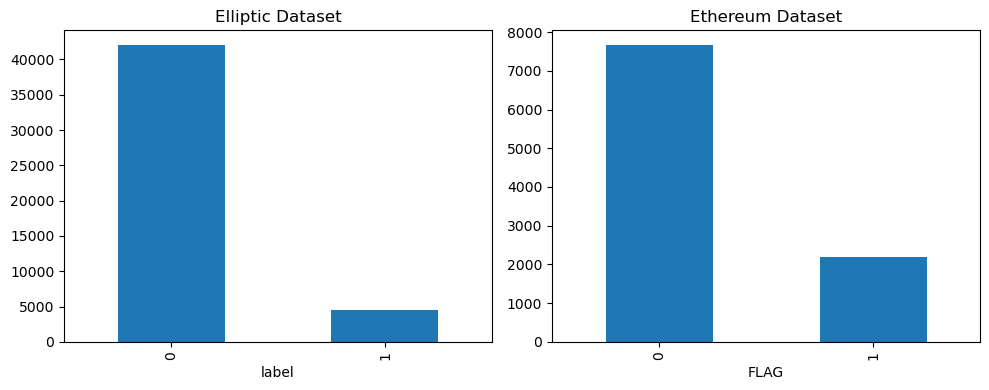

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df_elliptic['label'].value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title("Elliptic Dataset")

eth['FLAG'].value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title("Ethereum Dataset")

plt.tight_layout()
plt.show()


In [67]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore


In [68]:
def dataset_statistics(df, class_column):
    stats = {}
    
    stats["num_instancias"] = df.shape[0]
    stats["num_features"] = df.shape[1] - 1  # exclui coluna target
    
    class_distribution = df[class_column].value_counts(normalize=True) * 100
    
    stats["proporcao_classes"] = class_distribution.to_dict()
    
    return stats


In [69]:
classes = pd.read_csv("datasets/elliptic_txs_classes.csv")

elliptic_stats = dataset_statistics(classes, "class")
ethereum_stats = dataset_statistics(eth, "FLAG")

print("Elliptic:", elliptic_stats)
print("Ethereum:", ethereum_stats)


Elliptic: {'num_instancias': 203769, 'num_features': 1, 'proporcao_classes': {'unknown': 77.14863399241297, '2': 20.62089915541618, '1': 2.2304668521708404}}
Ethereum: {'num_instancias': 9841, 'num_features': 50, 'proporcao_classes': {0: 77.85794126613149, 1: 22.14205873386851}}


In [70]:
def outlier_analysis(df, exclude_columns=None):
    if exclude_columns is None:
        exclude_columns = []
        
    numeric_df = df.select_dtypes(include=[np.number]).drop(columns=exclude_columns, errors="ignore")
    
    results = {}
    
    # Z-score
    z_scores = np.abs(zscore(numeric_df, nan_policy='omit'))
    z_outliers = (z_scores > 3).any(axis=1)
    results["zscore_pct"] = round(z_outliers.mean() * 100, 2)
    
    # IQR
    Q1 = numeric_df.quantile(0.25)
    Q3 = numeric_df.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    iqr_outliers = ((numeric_df < lower_bound) | (numeric_df > upper_bound)).any(axis=1)
    results["iqr_pct"] = round(iqr_outliers.mean() * 100, 2)
    
    return results


In [71]:
# elliptic_outliers = outlier_analysis(elliptic_df, exclude_columns=["class"])
# ethereum_outliers = outlier_analysis(ethereum_df, exclude_columns=["FLAG"])

# print("Elliptic:", elliptic_outliers)
# print("Ethereum:", ethereum_outliers)


In [72]:
def graph_statistics(G):
    stats = {}
    
    stats["num_nos"] = G.number_of_nodes()
    stats["num_arestas"] = G.number_of_edges()
    
    degrees = [d for n, d in G.degree()]
    
    stats["grau_medio"] = round(np.mean(degrees), 2)
    stats["grau_maximo"] = np.max(degrees)
    
    stats["densidade"] = round(nx.density(G), 6)
    
    stats["componentes_conectados"] = nx.number_connected_components(G)
    
    return stats


In [73]:
#elliptic_graph_stats = graph_statistics(G)
ethereum_graph_stats = graph_statistics(G_eth)

#print("Elliptic Graph:", elliptic_graph_stats)
print("Ethereum Graph:", ethereum_graph_stats)


Ethereum Graph: {'num_nos': 9841, 'num_arestas': 33896, 'grau_medio': np.float64(6.89), 'grau_maximo': np.int64(15), 'densidade': 0.0007, 'componentes_conectados': 1}


In [74]:
comparison_table = pd.DataFrame({
    "Elliptic": {
        **elliptic_stats,
        **elliptic_graph_stats
    },
    "Ethereum": {
        **ethereum_stats,
        **ethereum_graph_stats
    }
})

print(comparison_table)


NameError: name 'elliptic_graph_stats' is not defined

In [ ]:
comparison_table


In [ ]:
comparison_table.T
